**INF 610 - Estruturas de Dados e Algoritmos**

Atividade Complementar - Filas de Prioridade e Árvores de Huffman

Aymê Faustino - 4704

In [122]:
import os
import math
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import struct
from collections import Counter

### Filas de Prioridade

Uma **Fila de Prioridade** é uma estrutura de dados abstrata em que cada elemento
possui uma prioridade associada. A operação de remoção sempre retorna o elemento de
maior (ou menor) prioridade, independentemente da ordem de inserção.

No contexto do Huffman Coding, a prioridade de cada nó é sua **frequência** e
sempre queremos extrair o nó de **menor** frequência. Por isso usamos uma fila de
prioridade de mínimo.

### Heap

O **Heap** é a estrutura de dados mais eficiente para implementar uma Fila de
Prioridade. Um Heap de mínimo é uma árvore binária que obedece a uma única regra:

> **O pai é sempre menor ou igual a seus filhos.**

Por consequência, o menor elemento está sempre na **raiz**.

O Heap é armazenado em um **array simples**, o que é possível porque a árvore é
sempre *completa*. Para um nó no índice $i$:

$$\text{filho esquerdo}(i) = 2i + 1 \qquad \text{filho direito}(i) = 2i + 2 \qquad \text{pai}(i) = \left\lfloor \frac{i-1}{2} \right\rfloor$$

### Árvores de Huffman

A Árvore de Huffman é uma árvore binária construída a partir das frequências dos
símbolos do texto. Os símbolos ficam nas **folhas**, e o código binário de cada
símbolo é determinado pelo caminho da raiz até sua folha:
ir para a esquerda acrescenta `"0"`, ir para a direita acrescenta `"1"`.

### Funcionamento geral do algoritmo

**Codificação:**
1. Contar a frequência de cada símbolo no texto.
2. Criar um nó `{símbolo, frequência}` para cada símbolo e inserir no Heap.
3. Repetir $n-1$ vezes: extrair os dois nós de menor frequência, criar um nó
   interno com frequência igual à soma dos dois, e reinserir no Heap.
4. O nó restante é a raiz da Árvore de Huffman.
5. Percorrer a árvore para gerar o dicionário de códigos binários.
6. Substituir cada símbolo do texto pelo seu código e salvar em `.huf`.

**Decodificação** (Seção 2.8.1 do livro de Salomon):
1. Receber a árvore construída na codificação.
2. Ler os bits do arquivo `.huf` e percorrer a árvore bit a bit:
   `"0"` → esquerda, `"1"` → direita.
3. Ao chegar em uma folha, emitir o símbolo e voltar à raiz.

### **Implementação do Heap como Fila de Prioridade**

In [123]:
class MinHeap:

    def __init__(self):
        self.heap = []       # Array que armazena os elementos
        self.operacoes = 0   # Contador de comparações para análise empírica

    def _sift_up(self, i):    # Sobe o elemento no índice i até sua posição correta.

        while i > 0:
            pai = (i - 1) // 2

            self.operacoes += 1                  # comparação
            if self.heap[i] < self.heap[pai]:
                self.heap[i], self.heap[pai] = self.heap[pai], self.heap[i]
                i = pai
            else:
                break

    def _sift_down(self, i):     #Afunda o elemento no índice i até sua posição correta.
        n = len(self.heap)

        while True:
            menor = i
            esq   = 2 * i + 1
            dir   = 2 * i + 2

            if esq < n:
                self.operacoes += 1              # comparação
                if self.heap[esq] < self.heap[menor]:
                    menor = esq

            if dir < n:
                self.operacoes += 1              # comparação
                if self.heap[dir] < self.heap[menor]:
                    menor = dir

            if menor != i:
                self.heap[i], self.heap[menor] = self.heap[menor], self.heap[i]
                i = menor
            else:
                break

    def heapify(self, lista):        # Monta o heap a partir de uma lista qualquer
        self.heap = list(lista)
        n = len(self.heap)
        for i in range(n // 2 - 1, -1, -1):
            self._sift_down(i)

    def push(self, item):           # Insere um novo item mantendo a propriedade do heap
        self.heap.append(item)
        self._sift_up(len(self.heap) - 1)

    def pop(self):                  # Remove e retorna o menor elemento (a raiz)
        if len(self.heap) == 0:
            raise IndexError("Heap vazio.")
        if len(self.heap) == 1:
            return self.heap.pop()
        raiz = self.heap[0]
        self.heap[0] = self.heap.pop()
        self._sift_down(0)
        return raiz

    def peek(self):                    # Retorna o menor elemento sem removê-lo
        if len(self.heap) == 0:
            raise IndexError("Heap vazio.")
        return self.heap[0]

    def __len__(self):                 # Retorna o número de elementos no heap
        return len(self.heap)

### Análise de Complexidade

**Função `_sift_up(i)`**

**Entrada:** $n$ = número de elementos no heap

**Operação básica:** comparação `self.heap[i] < self.heap[pai]`

A cada iteração, o elemento sobe um nível via `i → (i-1) // 2`, fazendo 1 comparação por nível. Sabemos que a altura de um heap com $n$ elementos é $H = \lfloor \log_2 n \rfloor$.

- **Melhor caso:** o elemento inserido já é maior que seu pai → 1 comparação → $\Omega(1)$
- **Pior caso:** o elemento sobe da folha até a raiz → $\lfloor \log_2 n \rfloor$ comparações

$$C_{\text{pior}}(n) = \sum_{k=1}^{\lfloor \log_2 n \rfloor} 1 = \lfloor \log_2 n \rfloor$$

- **Caso médio:** em média o elemento sobe metade da altura → $\Theta(\log n)$

Provando que $C(n) \in \Theta(\log n)$ pelo limite:

$$\lim_{n \to \infty} \frac{\lfloor \log_2 n \rfloor}{\log_2 n} = 1$$

Como o resultado é uma constante positiva: $C(n) \in \Theta(\log n)$.

---

**Função `_sift_down(i)`**

**Entrada:** $n$ = número de elementos no heap

**Operação básica:** comparações com os filhos esquerdo e direito

A cada nível o elemento desce comparando com seus dois filhos assim temos **no máximo 2 comparações por nível**.

- **Melhor caso:** o elemento já é menor que ambos os filhos → 2 comparações → $\Omega(1)$
- **Pior caso:** desce da raiz até uma folha percorrendo $\lfloor \log_2 n \rfloor$ níveis

$$C_{\text{pior}}(n) = \sum_{k=1}^{\lfloor \log_2 n \rfloor} 2 = 2\lfloor \log_2 n \rfloor$$

Provando que $C(n) \in \Theta(\log n)$ pelo limite:

$$\lim_{n \to \infty} \frac{2\lfloor \log_2 n \rfloor}{\log_2 n} = 2$$

Como o resultado é uma constante positiva: $C(n) \in \Theta(\log n)$.

**Equação de recorrência e Teorema Mestre**

O comportamento recursivo do `_sift_down` pode ser descrito pela recorrência: faz $O(1)$ comparações no nó atual e chama a si mesmo em uma subárvore de tamanho $\lfloor n/2 \rfloor$:

$$T(n) = T\!\left(\frac{n}{2}\right) + O(1)$$

Aplicando o **Teorema Mestre** com $a = 1$, $b = 2$, $f(n) = O(1)$:

$$n^{\log_b a} = n^{\log_2 1} = n^0 = 1$$

Como $f(n) = O(1) = \Theta(n^{\log_b a}) = \Theta(1)$, estamos no **Caso 2** do Teorema Mestre:

$$T(n) = \Theta(n^{\log_b a} \cdot \log n) = \Theta(\log n)$$

Isso confirma o resultado obtido pelo limite.

---

**Função `heapify(lista)`**

**Entrada:** $n$ = número de elementos na lista

**Operação básica:** comparações realizadas pelas chamadas de `_sift_down`

- **Melhor caso:** todos os elementos já estão na posição correta → cada `_sift_down` faz 2 comparações e para → $\Omega(n)$
- **Pior caso:** cada `_sift_down` percorre a altura máxima

O algoritmo executa `_sift_down` para cada nó interno do heap. Um nó de altura $k$ pode realizar no máximo $2k$ comparações, e existem no máximo $\lceil n/2^{k+1} \rceil$ nós com essa altura.

Assim, o número total de comparações é limitado por:

$$
C(n)
=
\sum_{k=1}^{\lfloor \log_2 n \rfloor}
\left\lceil \frac{n}{2^{k+1}} \right\rceil
\cdot 2k
$$

Logo,

$$
C(n)
\le
2n
\sum_{k=1}^{\infty}
\frac{k}{2^{k}}
$$

Como

$$
\sum_{k=1}^{\infty}
\frac{k}{2^{k}}
=
2,
$$

temos

$$
C(n)
\le
4n.
$$

Portanto,

$$
C(n)=O(n).
$$

Como o algoritmo percorre todos os nós internos do heap, também vale $C(n)=\Omega(n)$. Assim,

$$
C(n)\in\Theta(n).
$$
---

**Função `push(item)`**

**Entrada:** $n$ = número de elementos no heap após a inserção

**Operação básica:** comparação dentro de `_sift_up`

Insere no final e chama `_sift_up`. O custo é idêntico ao de `_sift_up`.

- **Melhor caso:** novo elemento é maior que o pai → 1 comparação → $\Omega(1)$
- **Pior caso:** novo elemento sobe até a raiz → $\lfloor \log_2 n \rfloor$ comparações
- **Caso médio:** $\Theta(\log n)$

$$C_{\text{pior}}(n) = \lfloor \log_2 n \rfloor \implies C(n) \in \Theta(\log n)$$

---

**Função `pop()`**

**Entrada:** $n$ = número de elementos no heap antes da remoção

**Operação básica:** comparações dentro de `_sift_down`

Move o último elemento para a raiz e chama `_sift_down(0)`. O custo é idêntico ao de `_sift_down`.

- **Melhor caso:** novo elemento na raiz já é menor que ambos os filhos → 2 comparações → $\Omega(1)$
- **Pior caso:** elemento desce até uma folha → $2\lfloor \log_2 n \rfloor$ comparações
- **Caso médio:** $\Theta(\log n)$

$$C_{\text{pior}}(n) = 2\lfloor \log_2 n \rfloor \implies C(n) \in \Theta(\log n)$$

---

**Função `peek()`**

**Entrada:** $n$ = número de elementos no heap

**Operação básica:** acesso a `self.heap[0]`

Retorna o elemento na posição 0 sem nenhuma comparação. O custo é constante em todos os casos.

- **Melhor, pior e médio caso:** $C(n) = 1$

$$\lim_{n \to \infty} \frac{1}{1} = 1 \implies C(n) \in \Theta(1)$$

---

**Função `__len__()`**

**Entrada:** $n$ = número de elementos no heap

**Operação básica:** chamada a `len(self.heap)`

Acesso direto, custo constante em todos os casos.

- **Melhor, pior e médio caso:** $C(n) = 1$

$$\lim_{n \to \infty} \frac{1}{1} = 1 \implies C(n) \in \Theta(1)$$

---

### Teste do Heap

In [124]:
heap_teste = MinHeap()
heap_teste.heapify([17, 9, 25, 5, 13, 11, 20])
print("Após heapify([17, 9, 25, 5, 13, 11, 20]):")
print("Array interno:", heap_teste.heap)
print("Raiz (deve ser 5):", heap_teste.peek())

heap_teste.push(3)
print("\nApós push(3):")
print("Array interno:", heap_teste.heap)
print("Raiz (deve ser 3):", heap_teste.peek())

print("\nExtraindo todos os elementos (devem sair em ordem crescente):")
saida = []
while len(heap_teste) > 0:
    saida.append(heap_teste.pop())
print(" ", saida)

Após heapify([17, 9, 25, 5, 13, 11, 20]):
Array interno: [5, 9, 11, 17, 13, 25, 20]
Raiz (deve ser 5): 5

Após push(3):
Array interno: [3, 5, 11, 9, 13, 25, 20, 17]
Raiz (deve ser 3): 3

Extraindo todos os elementos (devem sair em ordem crescente):
  [3, 5, 9, 11, 13, 17, 20, 25]


## **Questão a) - Implementação do Algoritmo de Huffman**

 As funções `Node`, `build_huffman_tree` e `generate_huffman_codes` foram adaptadas a partir do código fornecido pelo professor. A única modificação em `build_huffman_tree` é a substituição do `heapq` da biblioteca padrão pelo `MinHeap` implementado na seção anterior. Adicionalmente, foi implementada uma etapa de serialização da árvore de Huffman, armazenada junto ao arquivo comprimido para possibilitar sua reconstrução durante a decodificação.


#### Classe `Node`

In [125]:
class Node:
    def __init__(self, symbol=None, frequency=None):
        self.symbol = symbol
        self.frequency = frequency
        self.left = None
        self.right = None

    def __lt__(self, other):
        return self.frequency < other.frequency

#### `build_huffman_tree()`

In [126]:
def build_huffman_tree(chars, freq):
    nodes = [Node(char, f) for char, f in zip(chars, freq)]

    heap = MinHeap()
    heap.heapify(nodes)
    ops_heapify = heap.operacoes          # captura só o custo do heapify

    while len(heap) > 1:
        left  = heap.pop()
        right = heap.pop()
        merged = Node(frequency=left.frequency + right.frequency)
        merged.left  = left
        merged.right = right
        heap.push(merged)

    ops_construcao = heap.operacoes - ops_heapify   # só o loop

    return heap.pop(), ops_heapify, ops_construcao

#### `generate_huffman_codes()`

In [127]:
def generate_huffman_codes(node, code="", huffman_codes=None):
    if huffman_codes is None:
        huffman_codes = {}
    if node is not None:
        if node.symbol is not None:
            huffman_codes[node.symbol] = code
        generate_huffman_codes(node.left,  code + "0", huffman_codes)
        generate_huffman_codes(node.right, code + "1", huffman_codes)
    return huffman_codes

#### `huffman_encode()`

In [128]:
# serialização da árvore 
def _serialize_tree(node, bits: list):
    if node.symbol is not None:          # folha
        bits.append('1')
        bits.append(format(ord(node.symbol), '016b'))
    else:                                # nó interno
        bits.append('0')
        _serialize_tree(node.left, bits)
        _serialize_tree(node.right, bits)

def _deserialize_tree(bits: list, idx: list):
    if idx[0] >= len(bits):
        return None
    flag = bits[idx[0]]; idx[0] += 1
    if flag == '1':                      # folha
        byte_str = ''.join(bits[idx[0]:idx[0]+16])
        idx[0] += 16
        return Node(symbol=chr(int(byte_str, 2)))
    else:                                # nó interno
        node = Node()
        node.left = _deserialize_tree(bits, idx)
        node.right = _deserialize_tree(bits, idx)
        return node

def _bits_to_bytes(bits: str) -> bytes:
    padding = (8 - len(bits) % 8) % 8
    bits += '0' * padding
    b = bytearray([padding])
    for i in range(0, len(bits), 8):
        b.append(int(bits[i:i+8], 2))
    return bytes(b)

def _bytes_to_bits(data: bytes) -> str:
    padding = data[0]
    bits = ''.join(format(byte, '08b') for byte in data[1:])
    return bits if padding == 0 else bits[:-padding]

def huffman_encode(path):
    with open(path, "r", encoding="utf-8", errors="replace") as f:
        data = f.read()

    freq_map = {}
    for ch in data:
        freq_map[ch] = freq_map.get(ch, 0) + 1

    chars = list(freq_map.keys())
    freqs = list(freq_map.values())

    root, _, _ = build_huffman_tree(chars, freqs)
    codes = generate_huffman_codes(root)

    bits_texto = ''.join(codes[ch] for ch in data)

    tree_bits = []
    _serialize_tree(root, tree_bits)
    tree_bytes = _bits_to_bytes(''.join(tree_bits))
    tree_size_b = struct.pack('>I', len(tree_bytes))
    data_bytes = _bits_to_bytes(bits_texto)

    out_path = path + '.huf'
    with open(out_path, 'wb') as f:
        f.write(tree_size_b)
        f.write(tree_bytes)
        f.write(data_bytes)

    return root

In [129]:
def analisar(path):
    with open(path, "r", encoding="utf-8", errors="replace") as f:
        data = f.read()

    n = len(data)
    freq_map = {}
    for ch in data:
        freq_map[ch] = freq_map.get(ch, 0) + 1

    chars = list(freq_map.keys())
    freqs = list(freq_map.values())
    sigma = len(chars)

    root, ops_heapify, ops_construcao = build_huffman_tree(chars, freqs)


    original_size = os.path.getsize(path)
    compressed_size = os.path.getsize(path + '.huf')

    ops_arvore = ops_heapify + ops_construcao
    ops_codificacao = n
    ops_total = ops_arvore + ops_codificacao

    compression_ratio = original_size / compressed_size
    relative_size = 100 * compressed_size / original_size
    taxa_compressao = 1 - compressed_size / original_size
    bits_por_simbolo = (compressed_size * 8) / n

    return {
        'arquivo'          : os.path.basename(path),

        # características da entrada
        'n_chars'          : n,
        'sigma'            : sigma,

        # custo computacional
        'ops_heapify'      : ops_heapify,
        'ops_construcao'   : ops_construcao,
        'ops_arvore'       : ops_arvore,
        'ops_codificacao'  : ops_codificacao,
        'ops_total'        : ops_total,

        # tamanhos dos arquivos
        'original_bytes'   : original_size,
        'comprimido_bytes' : compressed_size,

        # métricas de compressão
        'compression_ratio': compression_ratio,
        'relative_size'    : relative_size,
        'taxa_compressao'  : taxa_compressao,
        'bits_por_simbolo' : bits_por_simbolo,
    }


> Para a análise empírica, foi adotada como operação básica principal a **comparação entre elementos do Heap**, contabilizada por meio do atributo `operacoes` da classe `MinHeap`. Dessa forma, os valores de `ops_heapify` e `ops_construcao` representam exclusivamente o número de comparações realizadas durante a construção da fila de prioridade e da árvore de Huffman.

> Na etapa de codificação do texto, não foram contabilizadas comparações individuais. Em vez disso, foi utilizada uma estimativa baseada no número de símbolos processados, representada por `ops_codificacao = n`, onde `n` corresponde ao tamanho do texto de entrada. Essa escolha foi adotada porque cada caractere precisa ser percorrido e convertido para seu respectivo código de Huffman, caracterizando um custo linear em relação ao tamanho da entrada.

> Assim, os resultados empíricos foram apresentados separando o custo da construção da árvore (`ops_heapify`, `ops_construcao` e `ops_arvore`) do custo da codificação (`ops_codificacao`). Essa separação permite observar experimentalmente as duas parcelas previstas pela análise teórica do algoritmo:

$$
\Theta(\sigma \log \sigma + n),
$$

> onde $\sigma$ representa o número de símbolos distintos e $n$ o tamanho do texto.

> Por fim, o valor `ops_total` corresponde à soma de `ops_arvore` e `ops_codificacao`. Como essa métrica agrega contagens obtidas por critérios diferentes (comparações no Heap e símbolos processados durante a codificação), ela deve ser interpretada apenas como uma estimativa do trabalho total realizado pelo algoritmo, sendo mais adequada para visualizar tendências de crescimento do que para comparar diretamente o número absoluto de operações executadas em cada etapa.



#### Teste Simples

In [130]:
chars = ["a", "b", "c", "d", "e", "f"]
freq  = [4,   7,   15,  17,  22,  42 ]

root, ops_heapify, ops_construcao = build_huffman_tree(chars, freq)
huffman_codes = generate_huffman_codes(root)

print("Códigos de Huffman (exemplo do enunciado):")
for char, code in huffman_codes.items():
    print(f"  Símbolo: {char}  →  Código: {code} ({len(code)} bits)")
print(f"\nComparações na construção: {ops_construcao}")

Códigos de Huffman (exemplo do enunciado):
  Símbolo: f  →  Código: 0 (1 bits)
  Símbolo: a  →  Código: 1000 (4 bits)
  Símbolo: b  →  Código: 1001 (4 bits)
  Símbolo: c  →  Código: 101 (3 bits)
  Símbolo: d  →  Código: 110 (3 bits)
  Símbolo: e  →  Código: 111 (3 bits)

Comparações na construção: 21


#### Testes Sinteticos

In [131]:
chars = ['a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n',
         'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z']

def synthetic_freqs(n_chars, chars):
    seed = 12345
    np.random.seed(seed)
    assert n_chars <= len(chars), 'Invalid number of characters.'
    valid_chars = chars[:n_chars]
    freqs = [np.random.randint(5, 100) for char in valid_chars]
    freqs = [freq / sum(freqs) for freq in freqs]
    symbol_dict = {char: freq for char, freq in zip(valid_chars, freqs)}
    return symbol_dict

def synthetic_file(symbol_dict, file_size, file_name):
    seed = 12345
    np.random.seed(seed)
    chars = list(symbol_dict.keys())
    freqs = list(symbol_dict.values())
    with open(file_name, 'w') as file:
        for i in range(file_size):
            file.write(np.random.choice(chars, p=freqs))

test_cases = [
    {'file_name': 'file_test1',  'num_chars': 4,  'file_size': 1000},
    {'file_name': 'file_test2',  'num_chars': 4,  'file_size': 10000},
    {'file_name': 'file_test3',  'num_chars': 4,  'file_size': 100000},
    {'file_name': 'file_test4',  'num_chars': 8,  'file_size': 1000},
    {'file_name': 'file_test5',  'num_chars': 8,  'file_size': 10000},
    {'file_name': 'file_test6',  'num_chars': 8,  'file_size': 100000},
    {'file_name': 'file_test7',  'num_chars': 16, 'file_size': 1000},
    {'file_name': 'file_test8',  'num_chars': 16, 'file_size': 10000},
    {'file_name': 'file_test9',  'num_chars': 16, 'file_size': 100000},
    {'file_name': 'file_test10', 'num_chars': 26, 'file_size': 1000},
    {'file_name': 'file_test11', 'num_chars': 26, 'file_size': 10000},
    {'file_name': 'file_test12', 'num_chars': 26, 'file_size': 100000},
]

In [132]:
def exibir_tabelas(df):
    # tabela de complexidade
    df_complexidade = df[
        [
            'arquivo',
            'n_chars',
            'sigma',
            'ops_heapify',
            'ops_construcao',
            'ops_arvore',
            'ops_codificacao',
            'ops_total'
        ]
    ].copy()

    print("\n=== análise de complexidade ===\n")
    print(df_complexidade.to_string(index=False))

    # tabela de compressão
    df_compressao = df[
        [
            'arquivo',
            'original_bytes',
            'comprimido_bytes',
            'compression_ratio',
            'relative_size',
            'taxa_compressao',
            'bits_por_simbolo'
        ]
    ].copy()

    df_compressao['compression_ratio'] = (
        df_compressao['compression_ratio']
    ).round(2)

    df_compressao['relative_size'] = (
        df_compressao['relative_size']
    ).round(2).astype(str) + '%'

    df_compressao['taxa_compressao'] = (
        df_compressao['taxa_compressao'] * 100
    ).round(2).astype(str) + '%'

    df_compressao['bits_por_simbolo'] = (
        df_compressao['bits_por_simbolo']
    ).round(4)

    print("\n=== métricas de compressão ===\n")
    print(df_compressao.to_string(index=False))

In [133]:
resultados = []

for test in test_cases:
    file_name = test['file_name']
    num_chars = test['num_chars']
    file_size = test['file_size']

    symbol_dict = synthetic_freqs(num_chars, chars)
    synthetic_file(symbol_dict, file_size, file_name)

    huffman_encode(file_name)

    resultados.append(analisar(file_name))

df_sintetico = pd.DataFrame(resultados)

exibir_tabelas(df_sintetico)


=== análise de complexidade ===

    arquivo  n_chars  sigma  ops_heapify  ops_construcao  ops_arvore  ops_codificacao  ops_total
 file_test1     1000      4            4               6          10             1000       1010
 file_test2    10000      4            4               6          10            10000      10010
 file_test3   100000      4            4               6          10           100000     100010
 file_test4     1000      8           10              37          47             1000       1047
 file_test5    10000      8           10              36          46            10000      10046
 file_test6   100000      8           10              36          46           100000     100046
 file_test7     1000     16           25             124         149             1000       1149
 file_test8    10000     16           25             123         148            10000      10148
 file_test9   100000     16           25             121         146           100000     100

#### Teste com Calgary

In [134]:
calgary_files = [
    "bib", "book1", "book2", "geo", "news.eml",
    "obj1", "obj2", "paper1", "paper2", "paper3",
    "paper4", "paper5", "paper6", "pic", "progc",
    "progl.txt", "progp", "trans"
]

base_path = '/home/ayme/Documentos/trabalho-eda/'

resultados_calgary = []

for nome in calgary_files:

    path = base_path + nome

    if not os.path.exists(path):
        print(f"{nome}: arquivo não encontrado.")
        continue

    huffman_encode(path)

    resultados_calgary.append(analisar(path))

df_calgary = pd.DataFrame(resultados_calgary)

exibir_tabelas(df_calgary)


=== análise de complexidade ===

  arquivo  n_chars  sigma  ops_heapify  ops_construcao  ops_arvore  ops_codificacao  ops_total
      bib   111261     81          150            1397        1547           111261     112808
    book1   768771     82          151            1420        1571           768771     770342
    book2   610856     96          178            1705        1883           610856     612739
      geo   100268    455          898           11752       12650           100268     112918
 news.eml   377109     98          182            1753        1935           377109     379044
     obj1    20529    196          374            4187        4561            20529      25090
     obj2   245739    277          546            6448        6994           245739     252733
   paper1    53161     95          172            1686        1858            53161      55019
   paper2    82199     91          164            1616        1780            82199      83979
   paper3    465

### Análise dos Resultados

Os experimentos com arquivos sintéticos mostram que o custo de construção da árvore depende
do tamanho do alfabeto e não do tamanho do arquivo. Para $\sigma = 16$, as
operações de construção variaram apenas entre 146 e 149, mesmo com $n$ crescendo
de $10^3$ para $10^5$. Ao aumentar $\sigma$, o custo cresce visivelmente: foram
10 operações para $\sigma = 4$ e aproximadamente 320 para $\sigma = 26$,
seguindo a curva $\Theta(\sigma \log \sigma)$ observada nos gráficos.

No Calgary Corpus, o comportamento se repete: `bib` e `book1`, com $\sigma$
parecido, apresentaram custos de construção de 1547 e 1571 operações
respectivamente, apesar de tamanhos bastante diferentes. O `geo` se destaca por
ter o maior alfabeto do corpus (455 símbolos), registrando 12650 operações de
construção.

A etapa de codificação percorre cada caractere do texto uma única vez, portanto
cresce linearmente com $n$. Em arquivos grandes, esse custo domina o total.

Em relação à compressão, alfabetos maiores produzem taxas menores, pois as
frequências ficam mais distribuídas e os códigos ficam mais longos. No corpus
sintético, a taxa caiu de aproximadamente 75% para 44% quando $\sigma$ foi de 4
para 26. No Calgary Corpus, `pic` obteve a melhor compressão com 82,89% e apenas
1,37 bits por símbolo, enquanto `trans` e `progc` ficaram abaixo de 35%, com
mais de 5 bits por símbolo.

Os resultados confirmam a análise teórica:

$$\Theta(n + \sigma \log \sigma)$$

#### Gráficos

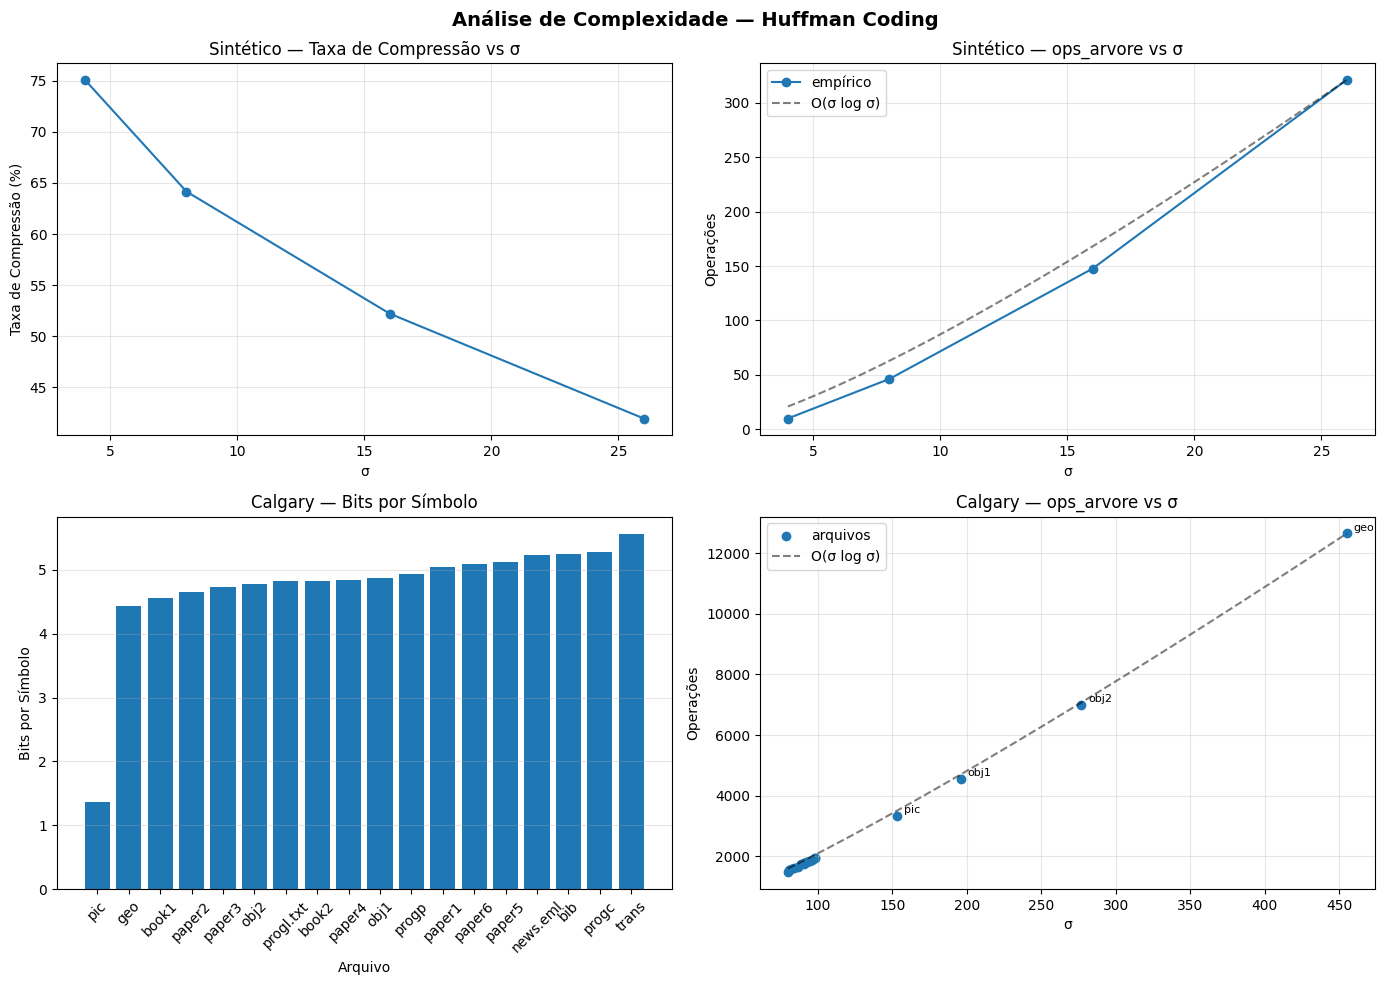

In [135]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Análise de Complexidade — Huffman Coding', fontsize=14, fontweight='bold')

# Sintético — Taxa de Compressão vs σ
ax = axes[0, 0]
sub = df.groupby('sigma')['taxa_compressao'].mean().reset_index()
ax.plot(sub['sigma'], sub['taxa_compressao'] * 100, marker='o')
ax.set(title='Sintético — Taxa de Compressão vs σ',
       xlabel='σ', ylabel='Taxa de Compressão (%)')
ax.grid(True, alpha=0.3)

# Sintético — ops_arvore vs σ
ax = axes[0, 1]
sub = df.groupby('sigma')['ops_arvore'].mean().reset_index().sort_values('sigma')
sigma_range = np.linspace(sub['sigma'].min(), sub['sigma'].max(), 100)
c = sub['ops_arvore'].iloc[-1] / (sub['sigma'].iloc[-1] * np.log2(sub['sigma'].iloc[-1]))

ax.plot(sub['sigma'], sub['ops_arvore'], marker='o', label='empírico')
ax.plot(sigma_range, c * sigma_range * np.log2(sigma_range),
        'k--', alpha=0.5, label='O(σ log σ)')
ax.set(title='Sintético — ops_arvore vs σ',
       xlabel='σ', ylabel='Operações')
ax.legend()
ax.grid(True, alpha=0.3)

# Calgary — Bits por símbolo
ax = axes[1, 0]

sub = df_calgary.sort_values('bits_por_simbolo')

ax.bar(sub['arquivo'],sub['bits_por_simbolo'])

ax.set( title='Calgary — Bits por Símbolo',xlabel='Arquivo',ylabel='Bits por Símbolo')

ax.tick_params(axis='x', rotation=45)
ax.grid(True, axis='y', alpha=0.3)

# Calgary — ops_arvore vs σ
ax = axes[1, 1]
ax.scatter(df_calgary['sigma'], df_calgary['ops_arvore'], label='arquivos')

for nome in ['geo', 'pic', 'obj1', 'obj2']:
    row = df_calgary[df_calgary['arquivo'] == nome].iloc[0]
    ax.annotate(nome, (row['sigma'], row['ops_arvore']),
                fontsize=8, xytext=(5, 2), textcoords='offset points')

sigma_range = np.linspace(df_calgary['sigma'].min(),
                          df_calgary['sigma'].max(), 100)

maior = df_calgary.loc[df_calgary['sigma'].idxmax()]
c = maior['ops_arvore'] / (maior['sigma'] * np.log2(maior['sigma']))

ax.plot(sigma_range, c * sigma_range * np.log2(sigma_range),
        'k--', alpha=0.5, label='O(σ log σ)')

ax.set(title='Calgary — ops_arvore vs σ',
       xlabel='σ', ylabel='Operações')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('complexidade_huffman.png', dpi=150, bbox_inches='tight')
plt.show()

### Análise dos Gráficos

> Taxa de Compressão × Número de Símbolos Distintos (Arquivos Sintéticos)

Nesse primeiro gráfico conseguimos ver uma redução da compressão à medida que $\sigma$ aumenta. Isso por que quando temos poucos símbolos distintos, o código desses símbolos ficam mais curtos, assim tendo uma maior taxa de compressão, logo também à medida que os śimbolos aumentam os códigos também aumentam e o ganho de compressão acaba diminuindo

Nos experimentos realizados, a taxa de compressão caiu de aproximadamente 75% para cerca de 42% quando $\sigma$ aumentou de 4 para 26..

---

> Operações de Construção da Árvore × $\sigma$ (Arquivos Sintéticos)

No segundo gráfico vemos que o resultado acompanha a curva que vimos na análise teórica, $O(\sigma \log \sigma)$. Pois sabemos que a construção da aŕvore realiza muitas inserções e remoções no heap e que cada uma delas tem custo  $O(\log \sigma)$.

Assim, os resultados confirmam que o custo de construção da árvore depende principalmente da quantidade de símbolos distintos presentes na entrada.


> Bits por Símbolo (Calgary Corpus)

O terceiro gráfico, mostra a apresenta a quantidade média de bits utilizada para representar cada símbolo após a compressão. Sabemos que quanto menor esse valor mais eficiente é a compressão.

Esse resultado evidencia uma característica importante do Huffman Coding: a eficiência da compressão depende não apenas da quantidade de símbolos distintos, mas principalmente da distribuição de suas frequências.

---

> Operações de Construção da Árvore × $\sigma$ (Calgary Corpus)

No último gráfico podemos observar também uma aderência ao comportamento que vimos nas análises teóricas de $O(\sigma \log \sigma)$. Vemos que o arquivo `geo`que tem a maior quantidade de símbolos distintos, também teve o maior custo de construção da árvore.

Esses resultados demonstram que a dependência observada nos testes sintéticos também se mantém em dados reais.

---


### **Questão b) - `huffman_decode()`**

A decodificação lê o arquivo `.huf` e reconstrói o texto original. Como dito anteriormente para que isso fosse possivel foi necessario giardar a árvore também no arquivo.

**Formato do arquivo `.huf`:**

| Campo | Tamanho | Conteúdo |
|---|---|---|
| Tamanho da árvore | 4 bytes | Inteiro com o número de bytes da árvore serializada |
| Árvore serializada | N bytes | Árvore em pré-ordem, convertida para bytes |
| Dados comprimidos | M bytes | Bits do texto codificado + padding |

**Serialização da árvore (pré-ordem):**

- **Folha** → bit `1` seguido de 16 bits do código Unicode do símbolo
- **Nó interno** → bit `0` seguido dos filhos esquerdo e direito recursivamente

**Algoritmo de decodificação:**

1. Ler os 4 primeiros bytes para saber o tamanho da árvore
2. Reconstroi a árvore a partir dos bytes seguintes
3. Percorrer os bits de dados: `0` → esquerda, `1` → direita
4. Ao atingir uma folha, emitir o símbolo e voltar à raiz
5. Repetir até consumir todos os bits

In [136]:
def huffman_decode(path_huf: str, out_path: str):
    with open(path_huf, 'rb') as f:
        raw = f.read()

    # lê tamanho da árvore
    tree_size = struct.unpack('>I', raw[:4])[0]
    tree_bytes = raw[4 : 4 + tree_size]
    data_bytes = raw[4 + tree_size :]

    # reconstrói árvore
    tree_bits = list(_bytes_to_bits(tree_bytes))
    idx  = [0]
    root = _deserialize_tree(tree_bits, idx)

    # decodifica texto
    data_bits = _bytes_to_bits(data_bytes)
    resultado = []
    node = root
    for bit in data_bits:
        node = node.left if bit == '0' else node.right
        if node.symbol is not None:      # folha
            resultado.append(node.symbol)
            node = root

    with open(out_path, 'w', encoding='utf-8') as f:
        f.write(''.join(resultado))

#### Teste nos arquivos sintéticos


In [137]:
print("=== Teste de Decode — Corpus Sintético ===\n")
todos_ok = True
for test in test_cases:
    file_name = test['file_name']

    huffman_decode(file_name + '.huf', file_name + '.recuperado')

    with open(file_name, 'r', encoding='utf-8', errors='replace') as f:
        original = f.read()
    with open(file_name + '.recuperado', 'r', encoding='utf-8', errors='replace') as f:
        recuperado = f.read()

    ok = original == recuperado
    todos_ok = todos_ok and ok
    status = '✓' if ok else '✗'
    print(f'{status} {file_name}: {len(original)} chars → idêntico={ok}')

print(f'\nTodos corretos: {todos_ok}')

=== Teste de Decode — Corpus Sintético ===

✓ file_test1: 1000 chars → idêntico=True
✓ file_test2: 10000 chars → idêntico=True
✓ file_test3: 100000 chars → idêntico=True
✓ file_test4: 1000 chars → idêntico=True
✓ file_test5: 10000 chars → idêntico=True
✓ file_test6: 100000 chars → idêntico=True
✓ file_test7: 1000 chars → idêntico=True
✓ file_test8: 10000 chars → idêntico=True
✓ file_test9: 100000 chars → idêntico=True
✓ file_test10: 1000 chars → idêntico=True
✓ file_test11: 10000 chars → idêntico=True
✓ file_test12: 100000 chars → idêntico=True

Todos corretos: True


#### Testes no Calgary

In [138]:
print("=== Teste de Decode — Calgary Corpus ===\n")
todos_ok = True
for nome in calgary_files:
    path = base_path + nome
    if not os.path.exists(path + '.huf'):
        print(f'  {nome}: .huf não encontrado, pulando.')
        continue

    huffman_decode(path + '.huf', path + '.recuperado')

    with open(path, 'r', encoding='utf-8', errors='replace') as f:
        original = f.read()
    with open(path + '.recuperado', 'r', encoding='utf-8', errors='replace') as f:
        recuperado = f.read()

    ok = original == recuperado
    todos_ok = todos_ok and ok
    status = '✓' if ok else '✗'
    print(f'{status} {nome}: {len(original)} chars → idêntico={ok}')

print(f'\nTodos corretos: {todos_ok}')

=== Teste de Decode — Calgary Corpus ===

✓ bib: 111261 chars → idêntico=True
✓ book1: 768771 chars → idêntico=True
✓ book2: 610856 chars → idêntico=True
✓ geo: 100268 chars → idêntico=True
✓ news.eml: 377109 chars → idêntico=True
✓ obj1: 20529 chars → idêntico=True
✓ obj2: 245739 chars → idêntico=True
✓ paper1: 53161 chars → idêntico=True
✓ paper2: 82199 chars → idêntico=True
✓ paper3: 46526 chars → idêntico=True
✓ paper4: 13286 chars → idêntico=True
✓ paper5: 11954 chars → idêntico=True
✓ paper6: 38105 chars → idêntico=True
✓ pic: 512405 chars → idêntico=True
✓ progc: 39611 chars → idêntico=True
✓ progl.txt: 71646 chars → idêntico=True
✓ progp: 49379 chars → idêntico=True
✓ trans: 91692 chars → idêntico=True

Todos corretos: True


Pelos testes vemos que a decodificação foi realizada com sucesso nos dois corpus de teste.

### **Questão c)- Análise de Complexidade Computacional**


O algoritmo de Huffman Coding pode ser decomposto nas seguintes etapas, cada uma com sua própria complexidade:

| Operação | Complexidade |
|---|---|
| Heapify | $O(\sigma)$ |
| Push / Pop | $O(\log \sigma)$ |
| Construção da árvore | $O(\sigma \log \sigma)$ |
| Geração dos códigos | $O(\sigma)$ |
| Codificação do texto | $O(n)$ |
| Decodificação | $O(n)$ |
| **Total** | $O(n + \sigma \log \sigma)$ |

onde $n$ é o número de caracteres no texto e $\sigma$ é o número de símbolos distintos.

> As operações do Heap (`heapify`, `push`, `pop`) foram analisadas na seção 
> anterior em função de $n$ (tamanho genérico do heap). No Huffman Coding, 
> o heap opera sobre os $\sigma$ símbolos do alfabeto — portanto, nas operações 
> do heap, $n$ assume o valor $\sigma$. Na codificação e decodificação, $n$ 
> refere-se ao número de caracteres do texto de entrada, que é independente de $\sigma$.

#### Construção da Árvore — $\Theta(\sigma \log \sigma)$

**Pseudocódigo:**
```
BUILD-HUFFMAN-TREE(chars, freqs):
  heap ← HEAPIFY([Node(c, f) para c, f em chars, freqs])
  enquanto |heap| > 1:
    esq  ← POP(heap)
    dir  ← POP(heap)
    novo ← Node(freq = esq.freq + dir.freq)
    PUSH(heap, novo)
  retorna POP(heap)
```

**Entrada:** $\sigma$ = número de símbolos distintos

**Operação básica:** comparações em `POP` e `PUSH`

- **Melhor caso:** igual ao pior — o loop sempre executa exatamente $\sigma - 1$ iterações independente das frequências → $\Omega(\sigma \log \sigma)$
- **Pior caso:** $\sigma - 1$ iterações, cada uma com 2 `POP` + 1 `PUSH`

$$T(\sigma) = \underbrace{O(\sigma)}_{\text{heapify}} + (\sigma - 1) \cdot 3 \cdot O(\log \sigma) = O(\sigma \log \sigma)$$

**Equação de recorrência:**

$$T(\sigma) = T(\sigma - 1) + O(\log \sigma), \quad T(1) = O(1)$$

Expandindo por substituição iterativa:

$$T(\sigma) = \sum_{k=2}^{\sigma} O(\log k)$$

Provando que $T(\sigma) \in \Theta(\sigma \log \sigma)$ pelo teorema do confronto:

$$\frac{\sigma/2 \cdot (\log \sigma - 1)}{\sigma \log \sigma} \leq \frac{\sum_{k=2}^{\sigma} \log k}{\sigma \log \sigma} \leq \frac{\sigma \cdot \log \sigma}{\sigma \log \sigma}$$

O limitante superior vem de $\log k \leq \log \sigma$ para todo $k \leq \sigma$. O limitante inferior vem do fato de que pelo menos metade dos termos satisfaz $k \geq \sigma/2$, logo $\log k \geq \log(\sigma/2) = \log \sigma - 1$.

Aplicando o limite nos dois lados:

$$\lim_{\sigma \to \infty} \frac{\sigma/2 \cdot (\log \sigma - 1)}{\sigma \log \sigma} = \frac{1}{2} \qquad \lim_{\sigma \to \infty} \frac{\sigma \cdot \log \sigma}{\sigma \log \sigma} = 1$$

Como o limite está espremido entre duas constantes positivas, pelo teorema do confronto:

$$T(\sigma) \in \Theta(\sigma \log \sigma)$$
---

#### Geração dos Códigos — $\Theta(\sigma)$

**Pseudocódigo:**
```
GENERATE-CODES(node, code, codes):
  se node é folha:
    codes[node.symbol] ← code
    retorna
  GENERATE-CODES(node.left,  code + "0", codes)
  GENERATE-CODES(node.right, code + "1", codes)
```

**Entrada:** $\sigma$ = número de símbolos distintos (folhas da árvore)

**Operação básica:** visita a cada nó da árvore

- **Melhor, pior e médio caso:** a travessia sempre visita todos os $2\sigma - 1$ nós da árvore

$$T(\sigma) = O(2\sigma - 1) = \Theta(\sigma)$$

---

#### Codificação do Texto — $\Theta(n)$

**Pseudocódigo:**
```
ENCODE(data, codes):
  bits ← ""
  para cada char c em data:
    bits ← bits + codes[c]
  retorna bits
```

**Entrada:** $n$ = número de caracteres no arquivo

**Operação básica:** lookup de cada caractere no dicionário de códigos

- **Melhor, pior e médio caso:** o loop sempre percorre todos os $n$ caracteres, cada lookup é $O(1)$

$$T(n) = \sum_{i=1}^{n} 1 = n \implies T(n) \in \Theta(n)$$

---

#### Decodificação — $\Theta(n)$

**Pseudocódigo:**
```
DECODE(bits, root):
  node ← root
  resultado ← []
  para cada bit b em bits:
    se b = '0': node ← node.left
    senão:      node ← node.right
    se node é folha:
      resultado ← resultado + [node.symbol]
      node ← root
  retorna resultado
```

**Entrada:** $n$ = número de caracteres a recuperar

**Operação básica:** passo na árvore para cada bit lido

- **Melhor caso:** todos os símbolos têm código de 1 bit → $\Omega(n)$
- **Pior caso:** códigos longos → mais bits por símbolo, mas ainda proporcional a $n$

O número total de bits é limitado por $n \cdot \lfloor \log_2 \sigma \rfloor$, e cada bit gera no máximo um caractere de saída:

$$T(n) \in \Theta(n)$$

---

#### Complexidade Total

Somando todas as etapas:

$$T(n, \sigma) = \underbrace{\Theta(\sigma)}_{\text{heapify}} + \underbrace{\Theta(\sigma \log \sigma)}_{\text{construção}} + \underbrace{\Theta(\sigma)}_{\text{códigos}} + \underbrace{\Theta(n)}_{\text{codificação}}$$

$$\boxed{T(n, \sigma) = \Theta(n + \sigma \log \sigma)}$$

Para textos reais, $n \gg \sigma$, então o termo que domina é $\Theta(n)$
```

#### Comparação Teoria × Empírico

As tabelas de razão $\text{ops}/(\sigma \log \sigma + n)$ permitem verificar formalmente a complexidade teórica. Pela definição de $\Theta$, se $T(n, \sigma) \in \Theta(n + \sigma \log \sigma)$, essa razão deve convergir para uma constante positiva. Os resultados confirmam essa suposição em ambos os corpus.


In [142]:
# --- corpus sintético ---
df_sintetico['f_teorico'] = (df_sintetico['n_chars'] + df_sintetico['sigma'] * np.log2(df_sintetico['sigma']))
df_sintetico['razao'] = df_sintetico['ops_total'] / df_sintetico['f_teorico']

tabela_sin = df_sintetico[['arquivo','n_chars','sigma',
                            'ops_total','f_teorico','razao']].copy()
tabela_sin.columns = ['arquivo','n','σ','ops medidas','Θ(n + σlogσ)','razão']
print("=== Corpus Sintético ===")
print(tabela_sin.to_string(index=False))
print(f"\nMédia : {df_sintetico['razao'].mean():.4f}")
print(f"Desvio : {df_sintetico['razao'].std():.4f}")
print(f"CV : {df_sintetico['razao'].std()/df_sintetico['razao'].mean()*100:.1f}%")

# --- Calgary Corpus ---
df_calgary['f_teorico'] = (df_calgary['n_chars'] + 
                            df_calgary['sigma'] * np.log2(df_calgary['sigma']))
df_calgary['razao'] = df_calgary['ops_total'] / df_calgary['f_teorico']

tabela_cal = df_calgary[['arquivo','n_chars','sigma',
                          'ops_total','f_teorico','razao']].copy()
tabela_cal.columns = ['arquivo','n','σ','ops medidas','Θ(n + σlogσ)','razão']
print("\n=== Calgary Corpus ===")
print(tabela_cal.to_string(index=False))
print(f"\nMédia : {df_calgary['razao'].mean():.4f}")
print(f"Desvio : {df_calgary['razao'].std():.4f}")
print(f"CV : {df_calgary['razao'].std()/df_calgary['razao'].mean()*100:.1f}%")

=== Corpus Sintético ===
    arquivo      n  σ  ops medidas  Θ(n + σlogσ)    razão
 file_test1   1000  4         1010   1008.000000 1.001984
 file_test2  10000  4        10010  10008.000000 1.000200
 file_test3 100000  4       100010 100008.000000 1.000020
 file_test4   1000  8         1047   1024.000000 1.022461
 file_test5  10000  8        10046  10024.000000 1.002195
 file_test6 100000  8       100046 100024.000000 1.000220
 file_test7   1000 16         1149   1064.000000 1.079887
 file_test8  10000 16        10148  10064.000000 1.008347
 file_test9 100000 16       100146 100064.000000 1.000819
file_test10   1000 26         1319   1122.211433 1.175358
file_test11  10000 26        10323  10122.211433 1.019836
file_test12 100000 26       100321 100122.211433 1.001985

Média : 1.0261
Desvio : 0.0522
CV : 5.1%

=== Calgary Corpus ===
  arquivo      n   σ  ops medidas  Θ(n + σlogσ)    razão
      bib 111261  81       112808 111774.527850 1.009246
    book1 768771  82       770342 769292.

No corpus sintético, a razão ficou próxima de 1 em todos os casos. A maior 
variação aparece quando o arquivo é pequeno e o alfabeto é grande, pois o custo 
de construir a árvore pesa mais no total. Conforme o arquivo cresce, a razão 
converge para 1.

No Calgary Corpus, o comportamento foi ainda mais estável. Os maiores desvios 
aparecem nos arquivos menores ou com alfabetos muito grandes, como `obj1` e 
`geo`, exatamente o que a teoria prevê.

Em ambos os corpora, a razão aproximadamente constante confirma empiricamente que:

$$T(n, \sigma) \in \Theta(n + \sigma \log \sigma)$$

O corpus sintético permite isolar o efeito de cada variável separadamente, 
enquanto o Calgary Corpus valida que o comportamento se mantém em arquivos reais.